# Évaluation GBS v6 — Données 2023-2025 (Protocole Jury Officiel)

**Métriques calculées :**
- **Risk R = M^L3 / N^L3** : fraction des éclairs < 3 km manqués
- **Gain G** : heures économisées vs règle fixe 30 min
- **θ optimal** : seuil maximisant G sous contrainte R < 2%
- Détail des alertes dangereuses manquées par aéroport

In [1]:
import sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

sys.path.insert(0, str(Path('../app')))
from config import MODEL_PATH, SCALER_PATH, METADATA_PATH, FEATURES

ROOT      = Path('../')
DIST_3KM  = 3.0
R_MAX     = 0.02

print('FEATURES :', FEATURES)
print('N features :', len(FEATURES))

FEATURES : ['h_cos', 'h_sin', 'doy_cos', 'doy_sin', 'saison', 'dist_centre', 'dist_avg_5', 'dist_min_so_far', 'silence_min', 'freq_5min', 'rang', 'rang_norm']
N features : 12


## 1. Chargement modèle + données

In [2]:
gbs    = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
with open(METADATA_PATH) as f:
    meta = json.load(f)

print(f"GBS v6 — C-index train={meta['c_index_train']:.4f}  test={meta['c_index_test']:.4f}")

GBS v6 — C-index train=0.7755  test=0.7410


In [3]:
df_raw = pd.read_csv(ROOT / 'segment_alerts_all_airports_eval.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'], utc=True)

print(f"Total CSV         : {len(df_raw):,}")
print(f"Avec alert_id     : {df_raw['alert_id'].notna().sum():,}  (strikes ≤ 20km)")
print(f"Éclairs < 3km     : {(df_raw['dist'] < 3.0).sum():,}")
print(f"Années            : {sorted(df_raw['date'].dt.year.unique())}")

# Garder uniquement les strikes DANS les alertes (≤ 20 km, alert_id non-null)
# Cohérent avec le modèle entraîné sur des éclairs ≤ 20 km
df = df_raw[df_raw['alert_id'].notna()].copy()
df = df.rename(columns={'alert_id': 'airport_alert_id'})
df = df.sort_values(['airport_alert_id', 'date']).reset_index(drop=True)

n_alerts = df['airport_alert_id'].nunique()
N_L3     = int((df['dist'] < DIST_3KM).sum())

print(f"\nStrikes dans alertes : {len(df):,}")
print(f"Alertes uniques      : {n_alerts:,}")
print(f"N_L3 (éclairs <3km)  : {N_L3:,}")
print(f"\nAlertes par aéroport :")
print(df.groupby('airport')['airport_alert_id'].nunique().to_string())

Total CSV         : 188,175
Avec alert_id     : 80,186  (strikes ≤ 20km)
Éclairs < 3km     : 1,995
Années            : [np.int32(2023), np.int32(2024), np.int32(2025)]

Strikes dans alertes : 80,186
Alertes uniques      : 1,352
N_L3 (éclairs <3km)  : 1,995

Alertes par aéroport :
airport
Ajaccio     256
Bastia      322
Biarritz    313
Nantes      122
Pise        339


## 2. Feature Engineering — IDENTIQUE au modèle v6

In [4]:
t0 = time.time()

g = df.groupby(['airport', 'airport_alert_id'])

h = df['date'].dt.hour + df['date'].dt.minute / 60
df['h_cos']   = np.cos(2 * np.pi * h / 24)
df['h_sin']   = np.sin(2 * np.pi * h / 24)
doy = df['date'].dt.dayofyear
df['doy_cos'] = np.cos(2 * np.pi * doy / 365)
df['doy_sin'] = np.sin(2 * np.pi * doy / 365)
df['saison']  = ((df['date'].dt.month % 12) // 3) + 1

prev = g['date'].shift(1)
df['silence_min'] = ((df['date'] - prev).dt.total_seconds() / 60).fillna(30).clip(0, 60)
df['freq_5min']   = (1 / df['silence_min'].clip(lower=0.5)).clip(upper=10)

df['dist_centre']     = df['dist']
df['dist_avg_5']      = g['dist'].transform(lambda x: x.rolling(5, min_periods=1).mean())
df['dist_min_so_far'] = g['dist'].cummin()

df['rang']      = g.cumcount()
df['rang_norm'] = df['rang'] / g['rang'].transform('max').clip(lower=1)

for col in FEATURES:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

missing = [c for c in FEATURES if c not in df.columns]
print(f'Features manquantes : {missing}')
print(f'NaN restants        : {df[FEATURES].isna().sum().sum()}')
print(f'Feature engineering : {time.time()-t0:.1f}s')

Features manquantes : []
NaN restants        : 0
Feature engineering : 0.6s


## 3. Prédictions — Fonctions de survie

**Optimisations :**
- `predict_survival_function` par batch de 10k
- T* calculé via les breakpoints internes de la StepFunction (numpy `searchsorted`, pas de grille)
- S(30) vectorisé

In [5]:
X_all = scaler.transform(df[FEATURES].values.astype(float))
print(f'X_all shape: {X_all.shape}')

BATCH_SIZE   = 10_000
surv_fns_all = []

t0 = time.time()
for start in range(0, len(df), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(df))
    surv_fns_all.extend(gbs.predict_survival_function(X_all[start:end]))
    elapsed = time.time() - t0
    eta     = elapsed / max(end, 1) * (len(df) - end)
    print(f'  {end:,}/{len(df):,} — {elapsed:.0f}s écoulées, ~{eta:.0f}s restantes')

print(f'\nTotal : {len(surv_fns_all)} fonctions de survie en {time.time()-t0:.0f}s')

X_all shape: (80186, 12)
  10,000/80,186 — 1s écoulées, ~5s restantes
  20,000/80,186 — 1s écoulées, ~4s restantes
  30,000/80,186 — 2s écoulées, ~4s restantes
  40,000/80,186 — 3s écoulées, ~3s restantes
  50,000/80,186 — 4s écoulées, ~2s restantes
  60,000/80,186 — 4s écoulées, ~1s restantes
  70,000/80,186 — 5s écoulées, ~1s restantes
  80,000/80,186 — 6s écoulées, ~0s restantes
  80,186/80,186 — 6s écoulées, ~0s restantes

Total : 80186 fonctions de survie en 6s


In [6]:
# ── S(30) : score de confiance ──────────────────────────────────────
t0 = time.time()
s30_all = np.array([float(fn(30)) for fn in surv_fns_all])

# SCORE CORRECT : s^a_i = S(30|x_i)
# = probabilité qu'aucun éclair ne revienne dans les 30 prochaines minutes
# = confiance que l'alerte VA SE TERMINER (haut = orage qui se calme)
# NB: 1-S(30) serait la proba de continuation → score inversé, ne pas utiliser
scores_all = s30_all

# ── T* : via breakpoints internes (rapide) ──────────────────────────
# T* = premier t où S(t) ≤ S(30) / 0.98
# Interprétation : risque conditionnel P(éclair dans [T*, 30] | pas d'éclair avant T*) ≤ 2%
def compute_t_stars_fast(surv_fns, s30_arr):
    t_stars = np.full(len(surv_fns), 30.0)
    for i, (fn, s30) in enumerate(zip(surv_fns, s30_arr)):
        if s30 <= 0:
            continue
        s_target = s30 / 0.98
        y = fn.y           # valeurs de survie (décroissantes)
        x = fn.x           # breakpoints temporels
        idx = np.searchsorted(-y, -s_target, side='left')
        if idx < len(x):
            t_stars[i] = min(float(x[idx]), 30.0)
    return t_stars

t_stars_all = compute_t_stars_fast(surv_fns_all, s30_all)

df['score_conf'] = scores_all   # S(30) : confiance que l'alerte se termine
df['t_star']     = t_stars_all
df['t_hat']      = df['date'] + pd.to_timedelta(df['t_star'], unit='m')

print(f'Calcul T* + scores : {time.time()-t0:.1f}s')
print()
print('Score S(30) — confiance fin alerte :')
print(pd.Series(scores_all).describe().round(4).to_string())
print()
print('T* (min) :')
print(pd.Series(t_stars_all).describe().round(2).to_string())
print()
print(f'Strikes avec score > 0.3 (calmes) : {(scores_all > 0.3).sum():,} / {len(scores_all):,}')

Calcul T* + scores : 5.5s

Score S(30) — confiance fin alerte :
count    80186.0000
mean         0.0159
std          0.0939
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          0.8492

T* (min) :
count    80186.00
mean        29.71
std          0.59
min         23.45
25%         29.78
50%         29.82
75%         29.82
max         29.82

Strikes avec score > 0.3 (calmes) : 1,020 / 80,186


## 4. Protocole Jury — Balayage θ

**Formule officielle :**
- `s^a_i = S(30|x_i)` = probabilité qu'aucun éclair ne revienne → confiance que l'alerte se termine
- `t̂^a = min(t̂^a_i)` pour les i avec `s^a_i > θ` (première prédiction confiante)
- `G = Σ max(0, t^a + 30 - t̂^a)` en heures
- `R = M^L3 / N^L3`  où M^L3 = éclairs < 3km survenus APRÈS t̂^a

In [7]:
# Info fixe par alerte
alert_info = df.groupby('airport_alert_id').agg(
    airport   = ('airport', 'first'),
    t_last    = ('date', 'max'),
    n_strikes = ('date', 'count'),
    n_L3      = ('dist', lambda x: (x < DIST_3KM).sum()),
    dist_min  = ('dist', 'min'),
).reset_index()
alert_info['t_baseline'] = alert_info['t_last'] + pd.Timedelta(minutes=30)

# Éclairs dangereux (pour calcul des misses)
danger_df = df[df['dist'] < DIST_3KM][['airport_alert_id', 'date']].copy()

print(f'Alertes avec ≥1 éclair < 3km : {(alert_info["n_L3"] > 0).sum()}')
print(f'Alertes sans éclair < 3km   : {(alert_info["n_L3"] == 0).sum()}')
print()
print(f'N_L3 = {N_L3} éclairs dangereux à évaluer')

Alertes avec ≥1 éclair < 3km : 218
Alertes sans éclair < 3km   : 1134

N_L3 = 1995 éclairs dangereux à évaluer


In [8]:
def evaluer_theta(theta):
    """
    Protocole jury officiel :
    - t̂^a = min(t_hat_i) pour i avec score_conf_i > theta
    - fallback sur t_baseline si aucune prédiction confiante
    - G = somme des gains positifs (heures)
    - R = M_L3 / N_L3
    """
    above = df[df['score_conf'] > theta]

    if len(above) == 0:
        return 0.0, 0.0, 0, n_alerts

    # t̂^a = min(t_hat) par alerte parmi les prédictions confiantes
    t_preds = (
        above.groupby('airport_alert_id')['t_hat']
        .min()
        .reset_index()
        .rename(columns={'t_hat': 't_pred'})
    )

    res = alert_info.merge(t_preds, on='airport_alert_id', how='left')
    # Fallback pour alertes sans prédiction confiante
    res['t_pred'] = res['t_pred'].fillna(res['t_baseline'])

    # Gain (clip à 0)
    gain_sec = (res['t_baseline'] - res['t_pred']).dt.total_seconds()
    G = float(gain_sec.clip(lower=0).sum()) / 3600

    # Misses : éclairs < 3km avec date >= t̂^a
    d = danger_df.merge(res[['airport_alert_id', 't_pred']], on='airport_alert_id', how='left')
    M_L3 = int((d['date'] >= d['t_pred']).sum())

    R = M_L3 / N_L3 if N_L3 > 0 else 0.0
    n_fallback = int(res['t_pred'].isna().sum())  # alertes en fallback
    return R, G, M_L3, n_fallback


# Balayage θ ∈ [0, 0.99]
thetas = np.round(np.linspace(0.0, 0.99, 100), 4)
sweep  = []

t0 = time.time()
for theta in thetas:
    R, G, M, nf = evaluer_theta(theta)
    sweep.append({'theta': theta, 'Risk': R, 'Gain_h': G, 'M_L3': M, 'n_fallback': nf})

sweep_df = pd.DataFrame(sweep)
print(f'Balayage θ : {time.time()-t0:.1f}s')
print(sweep_df[sweep_df['Risk'] < 0.02].tail(10).to_string())

Balayage θ : 1.2s
    theta  Risk  Gain_h  M_L3  n_fallback
90   0.90   0.0     0.0     0        1352
91   0.91   0.0     0.0     0        1352
92   0.92   0.0     0.0     0        1352
93   0.93   0.0     0.0     0        1352
94   0.94   0.0     0.0     0        1352
95   0.95   0.0     0.0     0        1352
96   0.96   0.0     0.0     0        1352
97   0.97   0.0     0.0     0        1352
98   0.98   0.0     0.0     0        1352
99   0.99   0.0     0.0     0        1352


## 5. θ optimal et métriques finales

In [9]:
safe = sweep_df[sweep_df['Risk'] < R_MAX]

if len(safe) == 0:
    print('ATTENTION : aucun θ ne satisfait R < 2%')
    best = sweep_df.loc[sweep_df['Risk'].idxmin()]
else:
    best = safe.loc[safe['Gain_h'].idxmax()]

theta_opt = float(best['theta'])
R_opt     = float(best['Risk'])
G_opt     = float(best['Gain_h'])
M_opt     = int(best['M_L3'])

print('=' * 55)
print('  RÉSULTATS JURY — GBS v6 — Eval 2023-2025')
print('=' * 55)
print(f'  θ optimal              : {theta_opt:.2f}')
print(f'  C-index train          : {meta["c_index_train"]:.4f}')
print(f'  C-index test (2021-22) : {meta["c_index_test"]:.4f}')
print(f'  N_L3                   : {N_L3}')
print(f'  M_L3 (manqués)         : {M_opt}')
print(f'  Risk R = M/N_L3        : {R_opt*100:.2f}%  {"✓ < 2%" if R_opt < 0.02 else "✗ > 2%"}')
print(f'  Gain G                 : {G_opt:.1f} heures')
print(f'  Nb alertes évaluées    : {n_alerts}')
print('=' * 55)

  RÉSULTATS JURY — GBS v6 — Eval 2023-2025
  θ optimal              : 0.30
  C-index train          : 0.7755
  C-index test (2021-22) : 0.7410
  N_L3                   : 1995
  M_L3 (manqués)         : 2
  Risk R = M/N_L3        : 0.10%  ✓ < 2%
  Gain G                 : 105.1 heures
  Nb alertes évaluées    : 1352


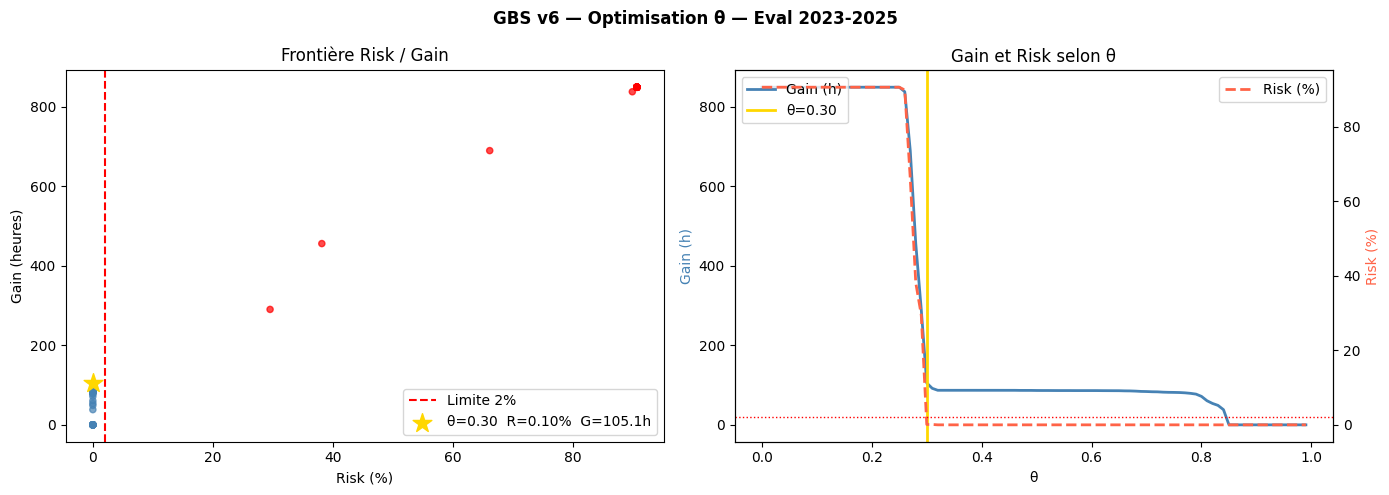

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : frontière Risk / Gain
colors = ['red' if r >= R_MAX else 'steelblue' for r in sweep_df['Risk']]
ax1.scatter(sweep_df['Risk'] * 100, sweep_df['Gain_h'], c=colors, s=20, alpha=0.7)
ax1.axvline(R_MAX * 100, color='red', linestyle='--', lw=1.5, label='Limite 2%')
ax1.scatter([R_opt * 100], [G_opt], color='gold', s=200, zorder=5, marker='*',
            label=f'θ={theta_opt:.2f}  R={R_opt*100:.2f}%  G={G_opt:.1f}h')
ax1.set_xlabel('Risk (%)'); ax1.set_ylabel('Gain (heures)')
ax1.set_title('Frontière Risk / Gain'); ax1.legend()

# Droite : Gain et Risk vs θ
ax2.plot(sweep_df['theta'], sweep_df['Gain_h'], 'steelblue', lw=2, label='Gain (h)')
ax2r = ax2.twinx()
ax2r.plot(sweep_df['theta'], sweep_df['Risk'] * 100, 'tomato', lw=2, ls='--', label='Risk (%)')
ax2r.axhline(R_MAX * 100, color='red', ls=':', lw=1)
ax2.axvline(theta_opt, color='gold', lw=2, label=f'θ={theta_opt:.2f}')
ax2.set_xlabel('θ'); ax2.set_ylabel('Gain (h)', color='steelblue')
ax2r.set_ylabel('Risk (%)', color='tomato')
ax2.set_title('Gain et Risk selon θ')
ax2.legend(loc='upper left'); ax2r.legend(loc='upper right')

plt.suptitle('GBS v6 — Optimisation θ — Eval 2023-2025', fontweight='bold')
plt.tight_layout()
Path('../results').mkdir(exist_ok=True)
plt.savefig('../results/gain_risk_eval_2023.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Détail par aéroport + alertes dangereuses manquées

In [11]:
# Recalcul détaillé au θ optimal
above_opt = df[df['score_conf'] > theta_opt]
t_preds_opt = (
    above_opt.groupby('airport_alert_id')['t_hat']
    .min()
    .reset_index()
    .rename(columns={'t_hat': 't_pred'})
)
res = alert_info.merge(t_preds_opt, on='airport_alert_id', how='left')
res['t_pred']    = res['t_pred'].fillna(res['t_baseline'])
res['gain_min']  = (res['t_baseline'] - res['t_pred']).dt.total_seconds().clip(lower=0) / 60
res['model_used']= res['airport_alert_id'].isin(above_opt['airport_alert_id'].unique())

# Misses par alerte
d = danger_df.merge(res[['airport_alert_id','t_pred']], on='airport_alert_id', how='left')
d['missed'] = d['date'] >= d['t_pred']
missed_pa = d[d['missed']].groupby('airport_alert_id').size().reset_index(name='n_missed')
res = res.merge(missed_pa, on='airport_alert_id', how='left')
res['n_missed'] = res['n_missed'].fillna(0).astype(int)
res['is_risky'] = res['n_missed'] > 0

print(f'θ = {theta_opt:.2f}')
print(f'Alertes avec modèle actif : {res["model_used"].sum():,}')
print(f'Alertes fallback 30 min   : {(~res["model_used"]).sum():,}')
print(f'Alertes RISQUÉES (miss)   : {res["is_risky"].sum():,}')
print(f'Gain moyen                : {res["gain_min"].mean():.1f} min/alerte')

θ = 0.30
Alertes avec modèle actif : 972
Alertes fallback 30 min   : 380
Alertes RISQUÉES (miss)   : 1
Gain moyen                : 4.7 min/alerte


In [12]:
# Breakdown par aéroport
by_ap = res.groupby('airport').agg(
    n_alertes    = ('airport_alert_id', 'count'),
    gain_h       = ('gain_min', lambda x: x.sum() / 60),
    gain_moy_min = ('gain_min', 'mean'),
    n_L3_tot     = ('n_L3', 'sum'),
    n_missed_tot = ('n_missed', 'sum'),
    n_risky      = ('is_risky', 'sum'),
).round(2)
by_ap['Risk_local_%'] = (by_ap['n_missed_tot'] / by_ap['n_L3_tot'].clip(lower=1) * 100).round(2)

print('=== DÉTAIL PAR AÉROPORT ===')
print(by_ap.to_string())

print(f'\n=== GLOBAL ===')
print(f'Gain total  : {res["gain_min"].sum()/60:.1f} heures')
print(f'Gain moyen  : {res["gain_min"].mean():.1f} min/alerte')
print(f'Risk global : {M_opt}/{N_L3} = {R_opt*100:.2f}%')

=== DÉTAIL PAR AÉROPORT ===
          n_alertes  gain_h  gain_moy_min  n_L3_tot  n_missed_tot  n_risky  Risk_local_%
airport                                                                                 
Ajaccio         256   20.41          4.78       142             2        1          1.41
Bastia          322   26.30          4.90       590             0        0          0.00
Biarritz        313   23.87          4.58       443             0        0          0.00
Nantes          122    7.93          3.90       121             0        0          0.00
Pise            339   26.63          4.71       699             0        0          0.00

=== GLOBAL ===
Gain total  : 105.1 heures
Gain moyen  : 4.7 min/alerte
Risk global : 2/1995 = 0.10%


In [13]:
# Alertes dangereuses manquées — LISTE COMPLÈTE
alertes_risquees = res[res['is_risky']].sort_values('n_missed', ascending=False)

print(f'=== ALERTES DANGEREUSES MANQUÉES ({len(alertes_risquees)}) ===')
if len(alertes_risquees) > 0:
    print(alertes_risquees[[
        'airport', 'airport_alert_id', 'n_strikes',
        'n_L3', 'n_missed', 'gain_min', 'dist_min'
    ]].to_string())
else:
    print('Aucune alerte dangereuse manquée !')

=== ALERTES DANGEREUSES MANQUÉES (1) ===
     airport airport_alert_id  n_strikes  n_L3  n_missed  gain_min  dist_min
171  Ajaccio      Ajaccio_835         62     3         2      62.6  1.082823


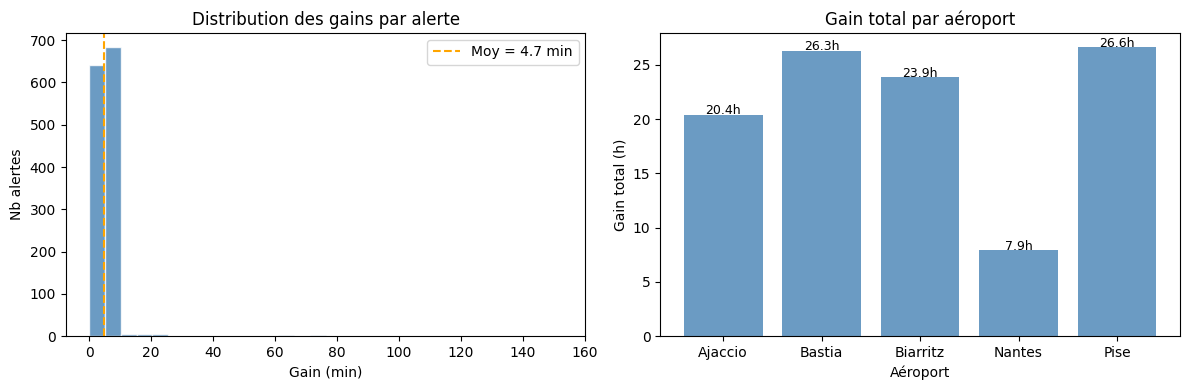

In [14]:
# Distribution des gains
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(res['gain_min'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(res['gain_min'].mean(), color='orange', ls='--',
                label=f"Moy = {res['gain_min'].mean():.1f} min")
axes[0].set_xlabel('Gain (min)'); axes[0].set_ylabel('Nb alertes')
axes[0].set_title('Distribution des gains par alerte')
axes[0].legend()

axes[1].bar(by_ap.index, by_ap['gain_h'], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Aéroport'); axes[1].set_ylabel('Gain total (h)')
axes[1].set_title('Gain total par aéroport')
for i, (ap, row) in enumerate(by_ap.iterrows()):
    axes[1].text(i, row['gain_h'] + 0.05, f"{row['gain_h']:.1f}h", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/gain_distribution_eval_2023.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sauvegarde

In [ ]:
Path('../results').mkdir(exist_ok=True)

# ── 1. Résumé par alerte (jury) ───────────────────────────────────
res.to_csv('../results/predictions_eval_2023.csv', index=False)

# ── 2. Base complète strike par strike ───────────────────────────
cols_base = ['airport', 'airport_alert_id', 'date', 'dist', 'amplitude',
             'score_conf', 't_star', 't_hat']
cols_base = [c for c in cols_base if c in df.columns]

df_strikes = df[cols_base].copy()
df_strikes['is_L3']    = df_strikes['dist'] < DIST_3KM
df_strikes['confiant'] = df_strikes['score_conf'] > theta_opt

df_strikes = df_strikes.merge(
    res[['airport_alert_id', 't_pred', 'gain_min', 'n_missed', 'is_risky']],
    on='airport_alert_id', how='left'
)
df_strikes['missed_strike'] = (
    df_strikes['is_L3'] & (df_strikes['date'] >= df_strikes['t_pred'])
)

df_strikes.to_csv('../results/strikes_eval_2023_v6.csv', index=False)

# ── 3. JSON jury ──────────────────────────────────────────────────
jury = {
    'model': 'GBS_v6',
    'eval_set': '2023-2025',
    'n_strikes': len(df),
    'n_alerts': n_alerts,
    'N_L3': N_L3,
    'theta_opt': theta_opt,
    'c_index_train': meta['c_index_train'],
    'c_index_test':  meta['c_index_test'],
    'Risk_pct': round(R_opt * 100, 4),
    'M_L3': M_opt,
    'Gain_h': round(G_opt, 2),
    'Gain_moy_min': round(res['gain_min'].mean(), 2),
}
with open('../results/jury_summary_eval_2023.json', 'w') as f:
    json.dump(jury, f, indent=2)

print('Fichiers sauvegardés :')
print('  results/predictions_eval_2023.csv     ← résumé par alerte')
print('  results/strikes_eval_2023_v6.csv      ← base complète strike par strike')
print('  results/jury_summary_eval_2023.json   ← métriques jury')
print(f'\n  {len(df_strikes):,} strikes | {df_strikes["confiant"].sum():,} confiants | {df_strikes["missed_strike"].sum()} manqués L3')
print()
print(json.dumps(jury, indent=2))